In [3]:
import numpy as np 

from pathlib import Path
import pandas as pd

from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt


In [4]:
data_dir = Path(r"X:\Personnel\MaryBeth\OpenScope\001709")

df = pd.read_csv(data_dir / "unit_info_with_rf.csv")
print(df.columns)
print(df.shape)

Index(['unit_id', 'mouse', 'plane', 'gmm_label', 'roi_id', 'rf_center_x',
       'rf_center_y', 'rf_r_squared'],
      dtype='object')
(6184, 8)


In [5]:
response_matrix = np.load(data_dir / "none"/ "response_matrix.npy")
print(response_matrix.shape)

response_norm = normalize(response_matrix, norm='l2')

(6184, 100)


In [6]:
mask = (
    (df["rf_center_x"] != 40) & (df["rf_center_x"] != -40) &
    (df["rf_center_y"] != 40) & (df["rf_center_y"] != -40)
)

df_filtered = df[mask]
response_filtered = response_norm[mask]

print(f"Neurons remaining: {len(df_filtered)}")

df = df_filtered
response_norm = response_filtered

Neurons remaining: 3745


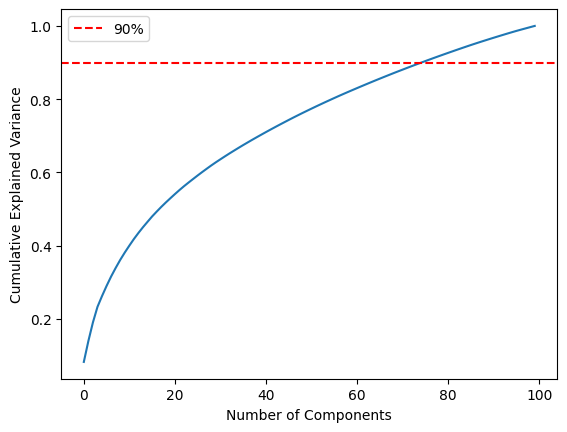

In [7]:
from sklearn.decomposition import PCA

X = response_norm.reshape(len(response_norm), -1)

# First see how many components explain most variance
pca = PCA()
pca.fit(X)  # your flattened response_norm

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.axhline(0.9, color='r', linestyle='--', label='90%')
plt.legend()
plt.show()

In [8]:
pca = PCA(n_components=77)  # adjust based on the plot
X_pca = pca.fit_transform(X)

In [55]:
print(df[["rf_center_x", "rf_center_y"]].describe())

       rf_center_x  rf_center_y
count  3745.000000  3745.000000
mean     -1.458725     1.531232
std      21.731585    19.894697
min     -39.979116   -39.994746
25%     -20.264272   -14.137764
50%      -3.104850     2.237022
75%      18.170368    17.921510
max      39.904667    39.784900


## 1. Ridge Regression

In [10]:
# regress location from response matrix
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

### With full response matrix

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, df[["rf_center_x", "rf_center_y"]], test_size=0.2, random_state=42
)

# Ridge
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"Ridge RMSE: {mean_squared_error(y_test, y_pred)**0.5:.4f}")

Ridge RMSE: 20.5425


### With GMM Cluster

In [12]:
X_train, X_test, y_train, y_test = train_test_split(df[["gmm_label"]], df[["rf_center_x", "rf_center_y"]], test_size=0.2, random_state=42)

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
#print(model.coef_)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print(f"Ridge RMSE: {mean_squared_error(y_test, y_pred)**0.5:.4f}")

Ridge RMSE: 20.7716


## 2. Partial Least Squares

### With full response matrix

In [14]:
# partial least squares regression
from sklearn.cross_decomposition import PLSRegression

In [15]:
X = response_norm.reshape(len(response_norm), -1)

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, df[["rf_center_x", "rf_center_y"]], test_size=0.2, random_state=42
)

model = PLSRegression(n_components=10)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"PLS RMSE: {mean_squared_error(y_test, y_pred)**0.5:.4f}")


PLS RMSE: 20.5802


## 3. Random Forest

In [16]:
# Random forest regression
from sklearn.ensemble import RandomForestRegressor

In [17]:
X = response_norm.reshape(len(response_norm), -1)

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, df[["rf_center_x", "rf_center_y"]], test_size=0.2, random_state=42
)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Random Forest RMSE: {mse**0.5:.4f}")

Random Forest RMSE: 20.2804


## 4. Neural Network

In [18]:
# Neural network regression
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler



In [19]:
# Flatten: (n_samples, h, w) -> (n_samples, h*w)
X = response_norm.reshape(len(response_norm), -1)

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, df[["rf_center_x", "rf_center_y"]], test_size=0.2, random_state=42
)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_s = scaler_X.fit_transform(X_train)
X_test_s = scaler_X.transform(X_test)
y_train_s = scaler_y.fit_transform(y_train)  # also scale the targets

nn = MLPRegressor(
    hidden_layer_sizes=(256, 128, 64),
    max_iter=2000,
    learning_rate_init=0.001,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)
nn.fit(X_train_s, y_train_s)

y_pred_s = nn.predict(X_test_s)
y_pred = scaler_y.inverse_transform(y_pred_s)  # back to original units

mse = mean_squared_error(y_test, y_pred)
print(f"MSE: {mse:.4f}")
print(f"RMSE: {mse**0.5:.4f}")

MSE: 430.4884
RMSE: 20.7482


## 5. Correlation

In [20]:
# e.g. does preferred orientation correlate with x/y position?
print(df[["rf_center_x", "rf_center_y", "gmm_label"]].corr())

             rf_center_x  rf_center_y  gmm_label
rf_center_x     1.000000    -0.053906   0.031282
rf_center_y    -0.053906     1.000000   0.032509
gmm_label       0.031282     0.032509   1.000000


In [33]:
n_clusters = df_filtered["gmm_label"].nunique()
print(f"Number of clusters: {n_clusters}")

cmap = plt.cm.get_cmap("turbo", n_clusters)  # turbo gives distinct colors across a large range

Number of clusters: 29


Text(0, 0.5, 'RF y')

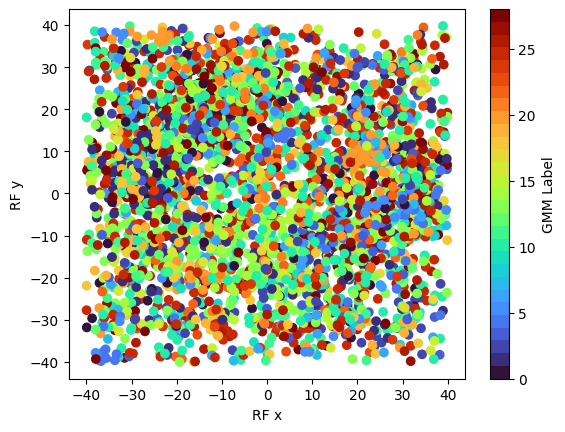

In [35]:
plt.scatter(df["rf_center_x"], df["rf_center_y"], c=df["gmm_label"], cmap=cmap)
plt.colorbar(label="GMM Label")
plt.xlabel("RF x"); plt.ylabel("RF y")

Number of clusters: 29


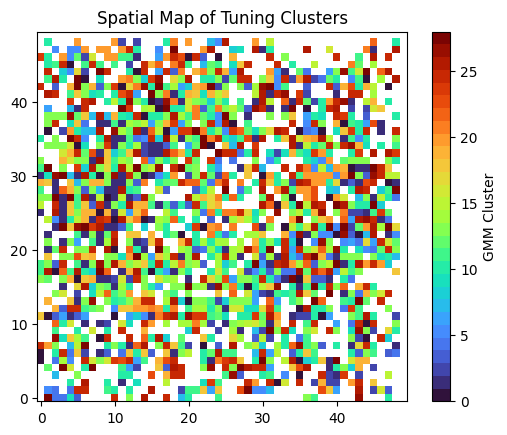

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create a 2D spatial map of cluster labels
# First define a grid over the visual field
grid_res = 50  # resolution of your spatial map
x_bins = np.linspace(-40, 40, grid_res)
y_bins = np.linspace(-40, 40, grid_res)

spatial_map = np.full((grid_res, grid_res), np.nan)

for _, row in df_filtered.iterrows():
    xi = np.digitize(row["rf_center_x"], x_bins) - 1
    yi = np.digitize(row["rf_center_y"], y_bins) - 1
    if 0 <= xi < grid_res and 0 <= yi < grid_res:
        spatial_map[yi, xi] = row["gmm_label"]

plt.imshow(spatial_map, origin="lower", cmap=cmap, vmin=0, vmax=n_clusters-1)
plt.colorbar(label="GMM Cluster")
plt.title("Spatial Map of Tuning Clusters")
plt.show()